In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor
import lightgbm as lgb          # imported as lgb so lgb.LGBMRegressor() works

print("All imports successful.")

All imports successful.


In [2]:
data = pd.read_csv("dataset_batting_features_v2.csv")
data["date"] = pd.to_datetime(data["date"])

# Sort chronologically — essential for leak-free splitting
data = data.sort_values(["date", "matchid"]).reset_index(drop=True)

print("Shape:", data.shape)
print("\nDate range:", data["date"].min(), "to", data["date"].max())
print("\nColumns:")
print(list(data.columns))

data.head()

Shape: (16439, 22)

Date range: 2008-04-18 00:00:00 to 2024-05-26 00:00:00

Columns:
['matchid', 'date', 'inning', 'batsman', 'batting_team', 'bowling_team', 'balls_faced', 'fours', 'sixes', 'dismissed', 'strike_rate', 'career_matches', 'career_avg_runs', 'career_strike_rate', 'form_runs_last_5', 'form_runs_last_10', 'form_sr_last_5', 'matches_vs_opponent', 'avg_runs_vs_opponent', 'is_first_innings', 'is_rookie', 'target_runs']


,matchid,date,inning,batsman,batting_team,bowling_team,balls_faced,fours,sixes,dismissed,...,career_avg_runs,career_strike_rate,form_runs_last_5,form_runs_last_10,form_sr_last_5,matches_vs_opponent,avg_runs_vs_opponent,is_first_innings,is_rookie,target_runs
0,335982,2008-04-18,2,aa noffke,royal challengers bangalore,kolkata knight riders,9,1,0,1,...,0.0,112.500000,1.666667,7.500000,60.000000,0,0.0,0,1,8
1,335982,2008-04-18,2,b akhil,royal challengers bangalore,kolkata knight riders,2,0,0,1,...,0.0,129.032258,13.000000,24.750000,132.996633,0,0.0,0,1,0
2,335982,2008-04-18,1,bb mccullum,kolkata knight riders,royal challengers bangalore,69,10,11,0,...,0.0,50.000000,1.000000,4.142857,46.666667,0,0.0,1,1,145
3,335982,2008-04-18,2,cl white,royal challengers bangalore,kolkata knight riders,8,0,0,0,...,0.0,88.888889,2.666667,2.500000,29.629630,0,0.0,0,1,4
4,335982,2008-04-18,1,dj hussey,kolkata knight riders,royal challengers bangalore,12,1,0,1,...,0.0,129.589041,16.750000,15.666667,103.634212,0,0.0,1,1,12


In [3]:
# Sanity checks — make sure no target leakage columns survived
forbidden_cols = ["runs_scored", "career_runs", "career_balls", "runs_vs_opponent_cumsum"]
leaked = [c for c in forbidden_cols if c in data.columns]

if leaked:
    print("WARNING — leaky columns found:", leaked)
else:
    print("No leaky columns detected.")

print("\nMissing values per column:")
print(data.isnull().sum()[data.isnull().sum() > 0])

No leaky columns detected.

Missing values per column:
Series([], dtype: int64)


In [4]:
split_index = int(len(data) * 0.8)

train = data.iloc[:split_index].copy()
test  = data.iloc[split_index:].copy()

print(f"Train size : {len(train):,} rows")
print(f"Test size  : {len(test):,} rows")
print(f"\nTrain date range: {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Test  date range: {test['date'].min().date()} → {test['date'].max().date()}")

Train size : 13,151 rows
Test size  : 3,288 rows

Train date range: 2008-04-18 → 2022-04-02
Test  date range: 2022-04-02 → 2024-05-26


In [5]:
# Define feature columns — all leak-free pre-match signals
FEATURES = [
    "career_matches",
    "career_avg_runs",
    "career_strike_rate",
    "form_runs_last_5",
    "form_runs_last_10",
    "form_sr_last_5",
    "matches_vs_opponent",
    "avg_runs_vs_opponent",
    "is_first_innings",
    "is_rookie"
]
TARGET = "target_runs"

# Verify all features exist
missing_features = [f for f in FEATURES if f not in data.columns]
if missing_features:
    print("ERROR — missing feature columns:", missing_features)
else:
    print("All features present.")

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")

All features present.

X_train: (13151, 10) | X_test: (3288, 10)


In [6]:
def evaluate(name, y_true, y_pred):
    """Print and return evaluation metrics for a model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  R²   : {r2:.3f}")
    print()
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []   # collect all model results here

In [7]:
# Use form_runs_last_10 computed during feature engineering as the baseline.
# This is already leak-free (shift(1) applied) so we can use it directly.
global_mean = y_train.mean()

# For test rows: use form_runs_last_10, fall back to training global mean
baseline_preds = test["form_runs_last_10"].fillna(global_mean).values

results.append(evaluate("Baseline (10-match Rolling Avg)", y_test, baseline_preds))

Baseline (10-match Rolling Avg)
  MAE  : 15.624
  RMSE : 20.876
  R²   : 0.068



In [8]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=2
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

results.append(evaluate("Random Forest (base)", y_test, rf_preds))

Random Forest (base)
  MAE  : 15.151
  RMSE : 20.347
  R²   : 0.115



In [9]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [6, 8],
    "min_samples_split": [5],
    "min_samples_leaf": [3]
}

gs_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=2
)

gs_rf.fit(X_train, y_train)

print("Best RF params:", gs_rf.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best RF params: {'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}


In [10]:
# Evaluate the tuned RF — best_rf_model is defined HERE (before any plots)
best_rf_model = gs_rf.best_estimator_
rf_tuned_preds = best_rf_model.predict(X_test)

results.append(evaluate("Random Forest (tuned)", y_test, rf_tuned_preds))

Random Forest (tuned)
  MAE  : 15.116
  RMSE : 20.303
  R²   : 0.118



In [11]:
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=2,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

results.append(evaluate("XGBoost", y_test, xgb_preds))

XGBoost
  MAE  : 15.572
  RMSE : 20.897
  R²   : 0.066



In [12]:
# lgb imported at top as: import lightgbm as lgb
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)

results.append(evaluate("LightGBM", y_test, lgb_preds))

LightGBM
  MAE  : 15.318
  RMSE : 20.713
  R²   : 0.083



In [13]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("MAE")
print(results_df.to_string(index=False))

                          model       MAE      RMSE       R2
          Random Forest (tuned) 15.116403 20.302951 0.118469
           Random Forest (base) 15.150851 20.346926 0.114646
                       LightGBM 15.318473 20.712989 0.082503
                        XGBoost 15.572347 20.896543 0.066170
Baseline (10-match Rolling Avg) 15.624111 20.876132 0.067993


/tmp/ipykernel_8556/2765364079.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["model"], rotation=20, ha="right", fontsize=9)
/tmp/ipykernel_8556/2765364079.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["model"], rotation=20, ha="right", fontsize=9)
/tmp/ipykernel_8556/2765364079.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["model"], rotation=20, ha="right", fontsize=9)


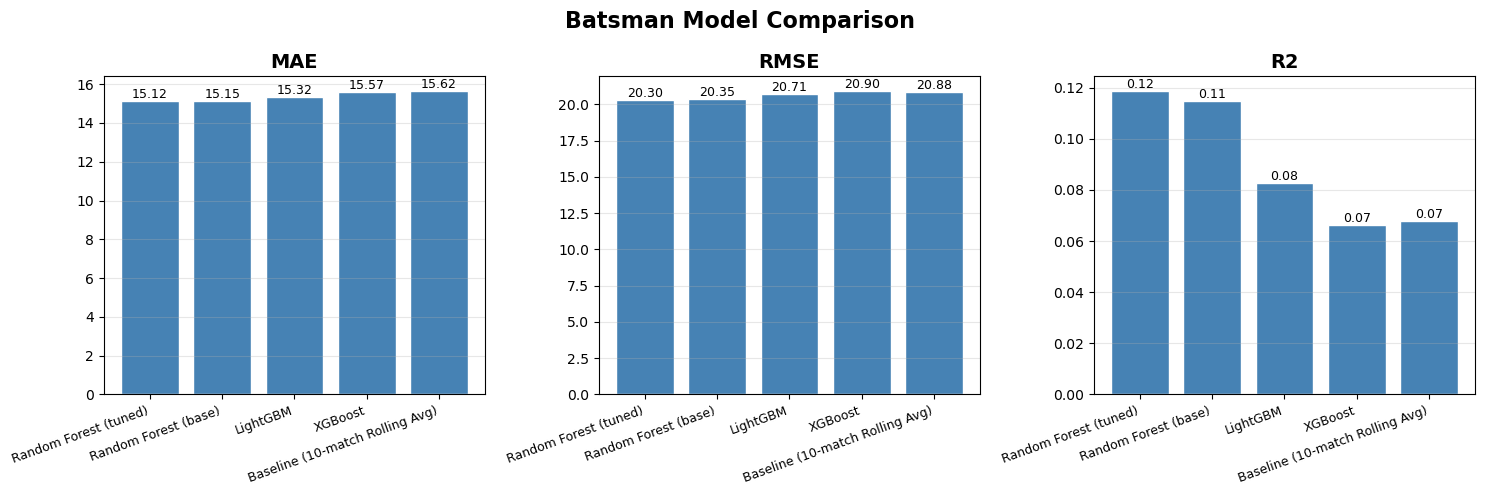

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    bars = ax.bar(results_df["model"], results_df[metric], color="steelblue", edgecolor="white")
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_xticklabels(results_df["model"], rotation=20, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Batsman Model Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
best_model_name = results_df.iloc[0]["model"]
print(f"Best model: {best_model_name}")

# Map name → predictions so we can reference the best predictions below
preds_map = {
    "Baseline (10-match Rolling Avg)": baseline_preds,
    "Random Forest (base)"           : rf_preds,
    "Random Forest (tuned)"          : rf_tuned_preds,
    "XGBoost"                        : xgb_preds,
    "LightGBM"                       : lgb_preds
}
best_preds = preds_map[best_model_name]

Best model: Random Forest (tuned)


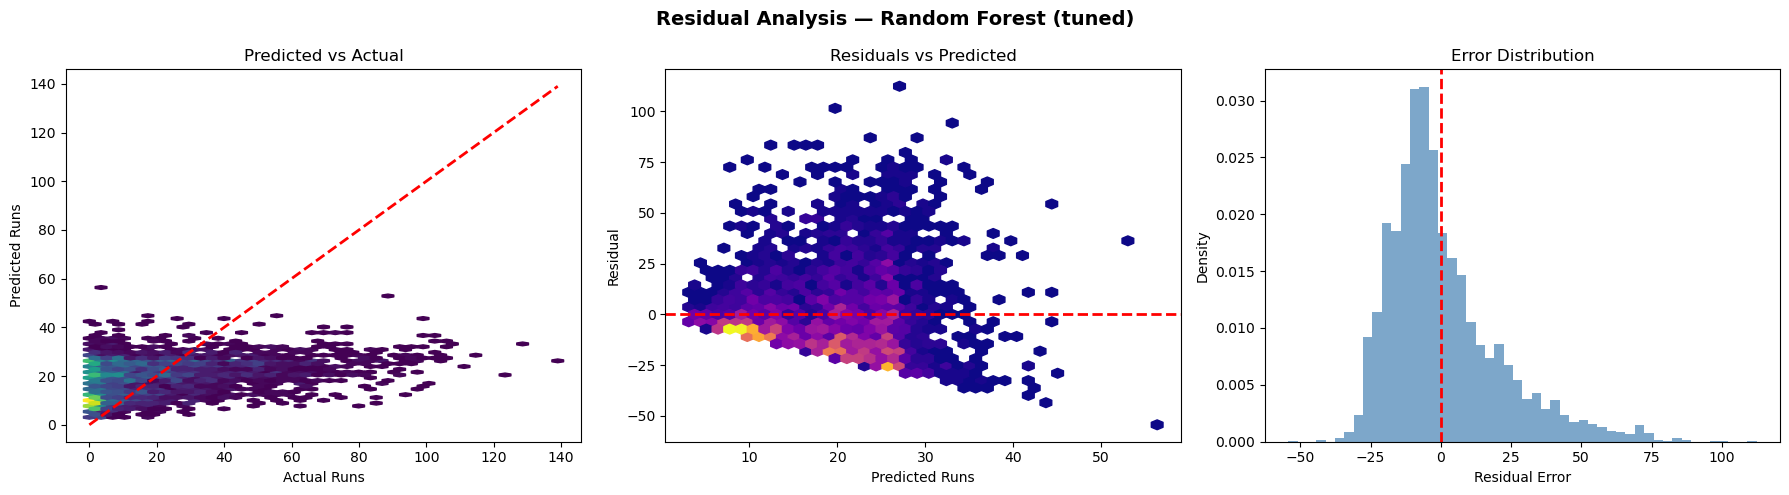

Mean residual : 0.835
Std  residual : 20.286


In [16]:
residuals = np.array(y_test) - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual
axes[0].hexbin(y_test, best_preds, gridsize=40, cmap="viridis", mincnt=1)
lims = [0, max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, "r--", linewidth=2)
axes[0].set_xlabel("Actual Runs")
axes[0].set_ylabel("Predicted Runs")
axes[0].set_title("Predicted vs Actual")

# Residuals vs Predicted
axes[1].hexbin(best_preds, residuals, gridsize=40, cmap="plasma", mincnt=1)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted Runs")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

# Error Distribution
axes[2].hist(residuals, bins=50, density=True, alpha=0.7, color="steelblue")
axes[2].axvline(0, color="red", linestyle="--", linewidth=2)
axes[2].set_xlabel("Residual Error")
axes[2].set_ylabel("Density")
axes[2].set_title("Error Distribution")

plt.suptitle(f"Residual Analysis — {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Mean residual : {residuals.mean():.3f}")
print(f"Std  residual : {residuals.std():.3f}")

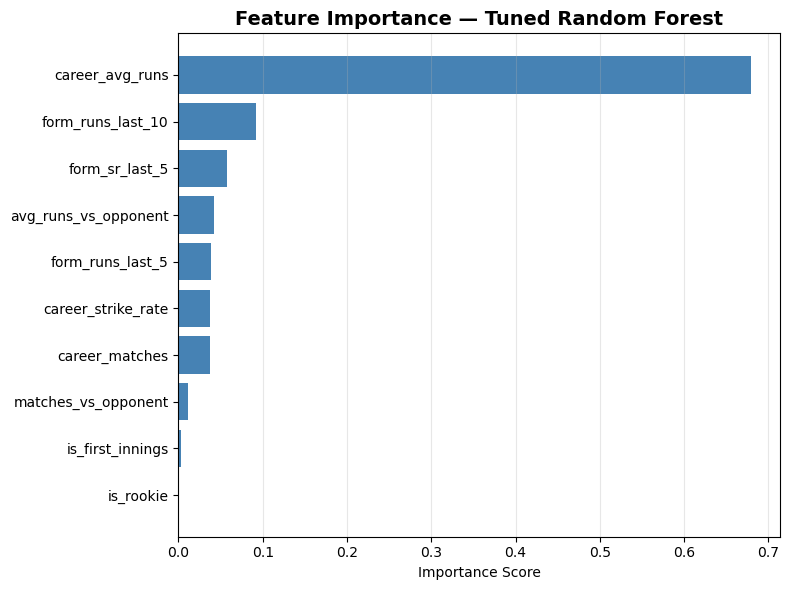

In [17]:
importance_df = pd.DataFrame({
    "feature"   : FEATURES,
    "importance": best_rf_model.feature_importances_
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
plt.title("Feature Importance — Tuned Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# Use TreeExplainer — works natively with RF, XGBoost, LightGBM
# We run SHAP on the tuned RF (swap model if XGBoost or LightGBM is best)
explainer = shap.TreeExplainer(best_rf_model)

# Sample 500 test rows for speed — SHAP on full test set can be slow
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values computed. Shape:", np.array(shap_values).shape)

SHAP values computed. Shape: (500, 10)


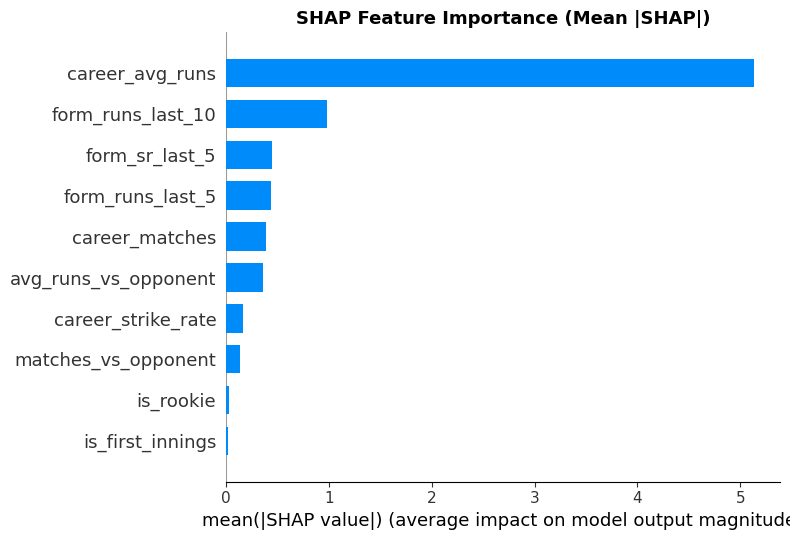

In [19]:
# Summary plot — global feature importance with direction
plt.figure()
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

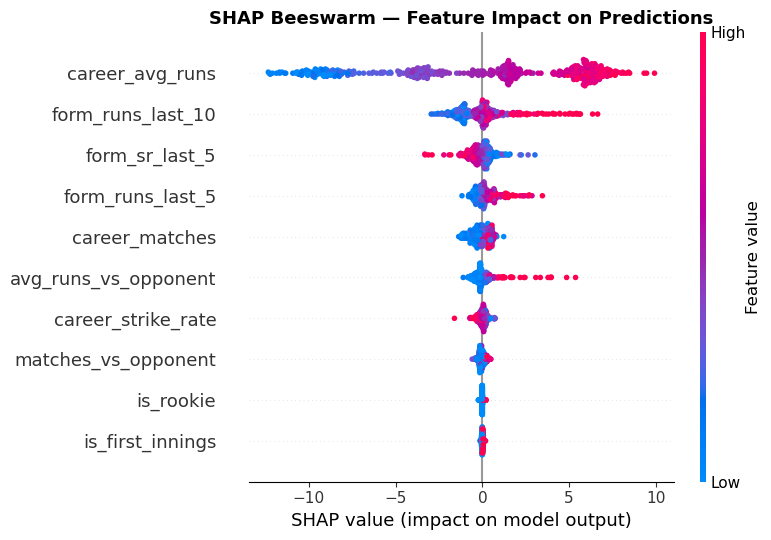

In [20]:
# Beeswarm plot — shows direction & magnitude per feature per sample
plt.figure()
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Beeswarm — Feature Impact on Predictions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

Explaining prediction for test row 0
  Actual runs  : 1
  Predicted    : 5.9


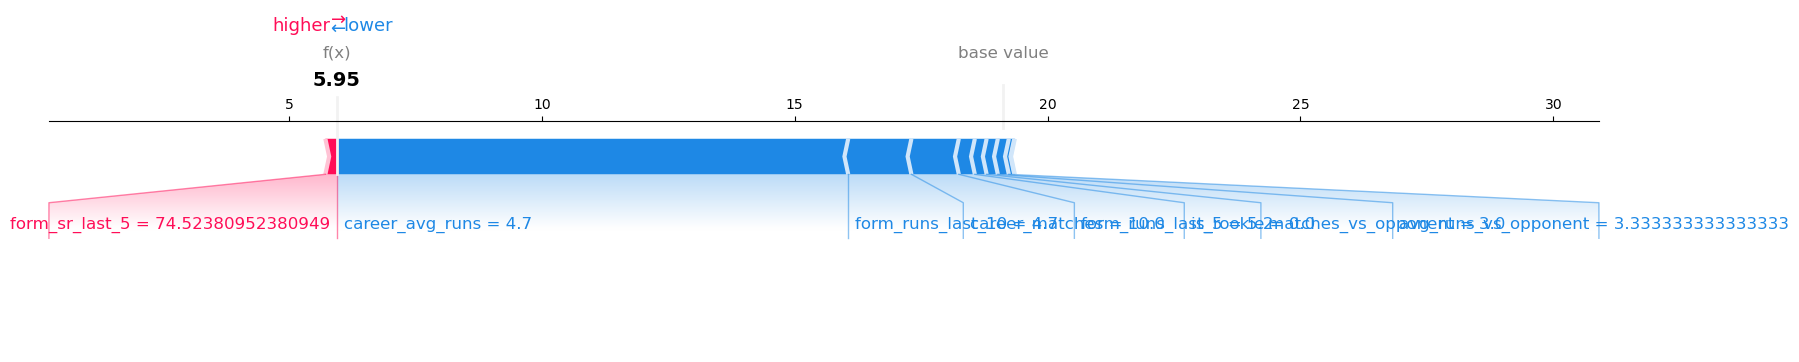

<Figure size 640x480 with 0 Axes>

In [21]:
# Force plot for a single prediction — useful for the Streamlit dashboard
sample_idx = 0
print(f"Explaining prediction for test row {sample_idx}")
print(f"  Actual runs  : {y_test.iloc[sample_idx]}")
print(f"  Predicted    : {best_rf_model.predict(X_test_sample.iloc[[sample_idx]])[0]:.1f}")

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test_sample.iloc[sample_idx],
    matplotlib=True
)
plt.savefig("shap_force_single.png", dpi=200, bbox_inches="tight")
plt.show()

In [22]:
# Save models
joblib.dump(best_rf_model, "batsman_rf_model.pkl")
joblib.dump(xgb_model,     "batsman_xgb_model.pkl")
joblib.dump(lgb_model,     "batsman_lgb_model.pkl")

# Save feature list so dashboard uses identical columns
joblib.dump(FEATURES, "feature_columns.pkl")

print("Saved:")
print("  batsman_rf_model.pkl")
print("  batsman_xgb_model.pkl")
print("  batsman_lgb_model.pkl")
print("  feature_columns.pkl")

Saved:
  batsman_rf_model.pkl
  batsman_xgb_model.pkl
  batsman_lgb_model.pkl
  feature_columns.pkl


In [23]:
def predict_batsman_runs(model, player_stats: dict) -> float:
    """
    Given a dict of pre-match player stats, return predicted runs.

    Parameters
    ----------
    model       : trained sklearn/xgb/lgb model
    player_stats: dict with keys matching FEATURES list

    Returns
    -------
    predicted runs (float)
    """
    features = joblib.load("feature_columns.pkl")
    row = pd.DataFrame([player_stats])[features]
    return float(model.predict(row)[0])


# Example — Virat Kohli style stats against CSK at home
example_input = {
    "career_matches"      : 220,
    "career_avg_runs"     : 37.5,
    "career_strike_rate"  : 130.2,
    "form_runs_last_5"    : 42.0,
    "form_runs_last_10"   : 38.5,
    "form_sr_last_5"      : 135.0,
    "matches_vs_opponent" : 18,
    "avg_runs_vs_opponent": 40.2,
    "is_first_innings"    : 1,
    "is_rookie"           : 0
}

pred = predict_batsman_runs(best_rf_model, example_input)
print(f"Predicted runs: {pred:.1f}")

Predicted runs: 29.1


---
## Summary

| Step | Status |
|------|--------|
| Imports (all 3 models + SHAP + matplotlib) | ✅ |
| Chronological train/test split | ✅ |
| Leak-free baseline on test split only | ✅ |
| Random Forest base + tuned (GridSearchCV) | ✅ |
| XGBoost | ✅ |
| LightGBM (`import lightgbm as lgb`) | ✅ |
| Unified MAE / RMSE / R² evaluation | ✅ |
| Residual analysis plots | ✅ |
| Feature importance plot | ✅ |
| SHAP summary + beeswarm + force plot | ✅ |
| All models + feature list serialized | ✅ |
| Prediction helper function for Streamlit | ✅ |

**Next step:** Build `streamlit_app.py` using `predict_batsman_runs()` and the saved `.pkl` files.